In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
# import both training and testing datasets
training = pd.read_csv('C:/Users/korej/Desktop/internship/day-14/MNIST dataset/MNIST dataset/train.csv')
testing = pd.read_csv('C:/Users/korej/Desktop/internship/day-14/MNIST dataset/MNIST dataset/test.csv')

In [3]:
training.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
training.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str', length=785)

In [5]:
testing.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
testing.columns

Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str', length=784)

In [7]:
#split training dataset to learning and goal columns (testing dataset doesn't have a label/target)
x = training.drop(['label'], axis = 1)
y = training['label']

In [8]:
x.shape

(42000, 784)

In [9]:
# pixels brightness is from 0-255, but i want it in range of 0-1
x = x.astype(float)/255.0
# for CNN we reshape it to 4 values, -1 is the start that is converted to 0 later by relu
# 28*28 was the shape of the pic, and 1 means it's greyscale if it's RGB (red-green-blue) then it'll be 2
x=x.to_numpy()
x = x.reshape(-1, 28, 28,1)

In [10]:
# encoding into array, 10 outputs since we want 0-9
y = to_categorical(y,10)

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
# conv layer detects features like  corner and edges and colors, while dense layer predicts the output
Cnn = models.Sequential([
    #no -1 in shape bcz -ve dimensuins are not allowed
     Conv2D(32, kernel_size=(3,3), activation='relu', input_shape = (28,28,1)), #kernel size means area of the batch it'll process
     MaxPool2D(pool_size=(2,2)), #restricting to the bright important area of 2*2 instead of the whole image
     Conv2D(64, kernel_size=(3,3), activation='relu'), #second layer
     MaxPool2D(pool_size=(2,2)),
     Flatten(), # convert to 1D, in ann and perceptron it's b4, but for cnn is after convulation so it can be fed into the output layer
     Dense(128, activation='relu'),
     Dropout(0.5), #takes 50% of the data first then later the others
     Dense(10, activation='softmax')

])

c:\Users\korej\anaconda3\envs\ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
Cnn.compile(optimizer='Adam',
            loss = 'categorical_crossentropy',
            metrics = ['Accuracy'])

In [15]:
loss_curve = Cnn.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - Accuracy: 0.9031 - loss: 0.3157 - val_Accuracy: 0.9741 - val_loss: 0.0881
Epoch 2/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - Accuracy: 0.9680 - loss: 0.1095 - val_Accuracy: 0.9795 - val_loss: 0.0680
Epoch 3/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - Accuracy: 0.9748 - loss: 0.0825 - val_Accuracy: 0.9845 - val_loss: 0.0574
Epoch 4/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - Accuracy: 0.9799 - loss: 0.0642 - val_Accuracy: 0.9844 - val_loss: 0.0587
Epoch 5/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - Accuracy: 0.9843 - loss: 0.0503 - val_Accuracy: 0.9862 - val_loss: 0.0499
Epoch 6/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - Accuracy: 0.9863 - loss: 0.0452 - val_Accuracy: 0.9874 - val_loss: 0.0479
Epoch 7/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - Accuracy: 0.9874 - loss: 0.0375 - val_Accuracy: 0.9881 - val_loss: 0.0502
Epoch 8/10
840/840 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - Accuracy: 0.9895 - loss: 0.0330 - val_Accuracy: 0

In [16]:
loss, acc = Cnn.evaluate(x_test, y_test)
print("Test Accuracy:", acc) # high accuracy means it's working well and we can implement it on the unlabeled

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - Accuracy: 0.9900 - loss: 0.0347
Test Accuracy: 0.9900000095367432


In [17]:
# for trainig it's working so well, now we'll try it on testing dataset, but we
# need to reshape, normlaize too
testing = testing.astype(float)/255.0
testing = testing.to_numpy()
testing = testing.reshape(-1,28,28,1)

In [18]:

predictions = Cnn.predict(testing)

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


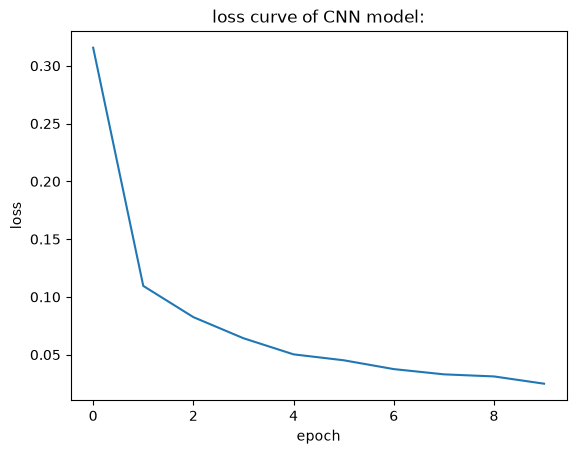

In [20]:
plt.Figure(figsize=(18,6))
plt.plot(loss_curve.history['loss'])
plt.title('loss curve of CNN model:')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()